In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/online-shoppers-intention/online_shoppers_intention.csv


In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline as Pipeline_
from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.under_sampling import NearMiss
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from xgboost import plot_importance
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import plot_tree

In [3]:
df = pd.read_csv("/kaggle/input/online-shoppers-intention/online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

The data does not have any null value.

In [5]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [6]:
categorical = ['OperatingSystems', 'Browser', 'Region', 'Month', 'Weekend', 'TrafficType', 'VisitorType', 'Revenue']
numerical = ['Administrative', 'Administrative_Duration',
             'Informational', 'Informational_Duration',
             'ProductRelated', 'ProductRelated_Duration',
             'BounceRates', 'ExitRates', 'PageValues']

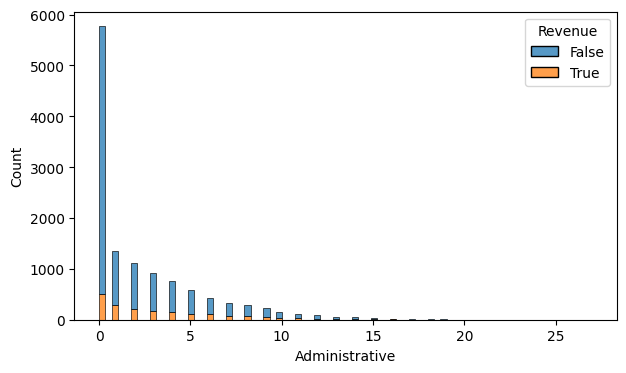

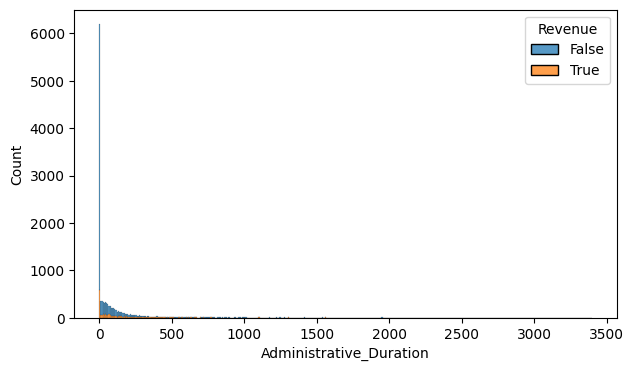

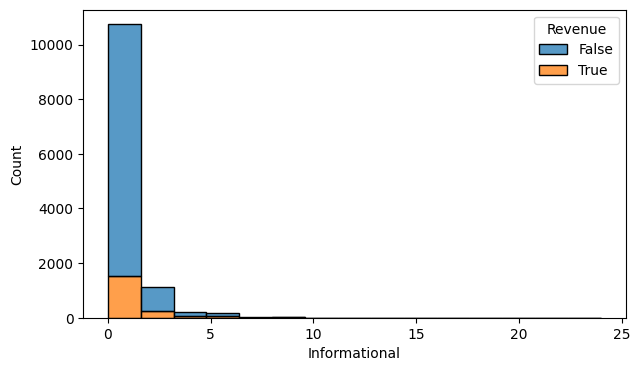

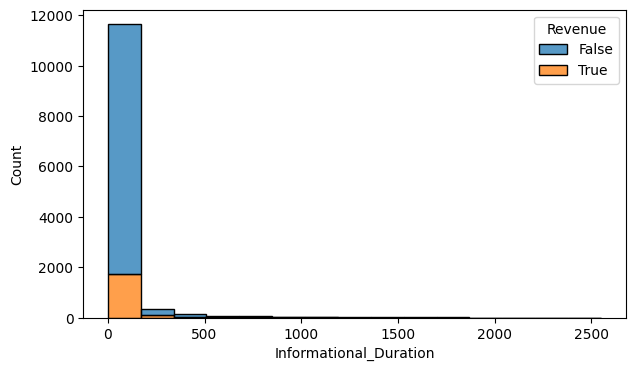

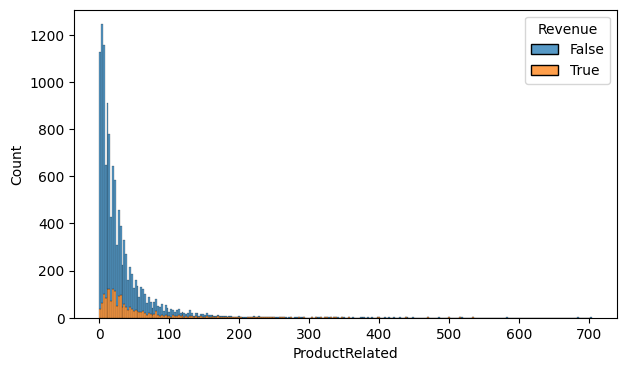

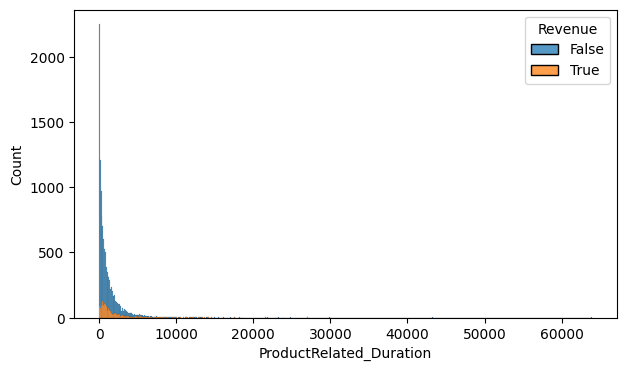

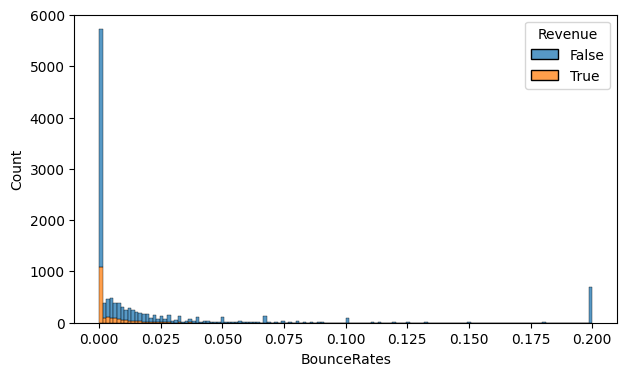

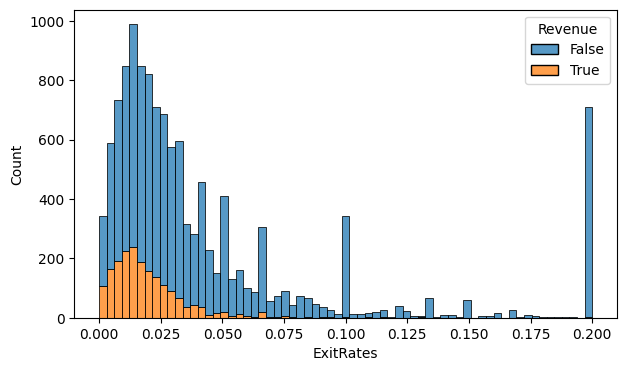

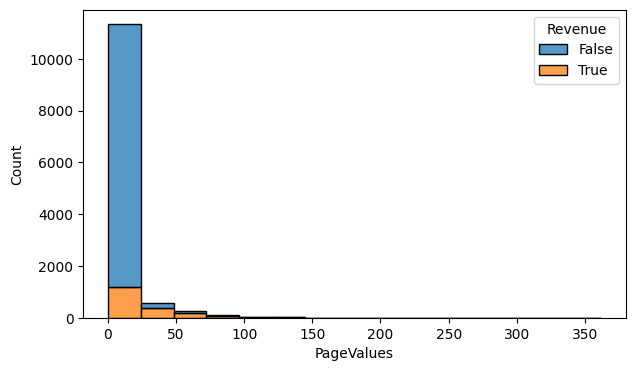

In [7]:
for num_col in numerical:
    plt.figure(figsize=(7,4))
    sns.histplot(df, x=num_col, hue='Revenue', multiple='stack')
    plt.show()

The numerical features has a high skew level

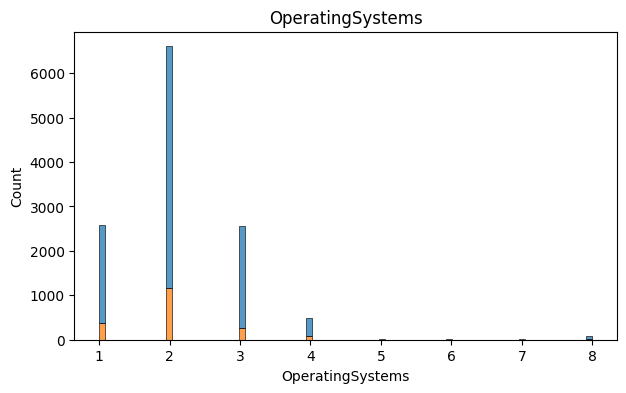

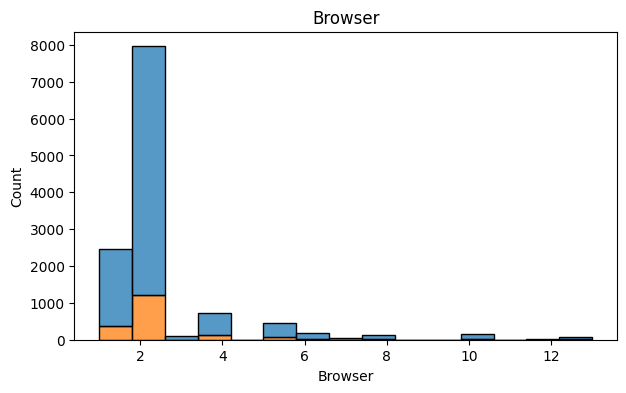

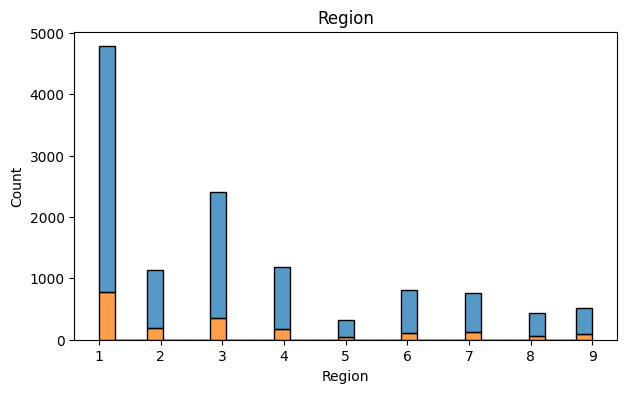

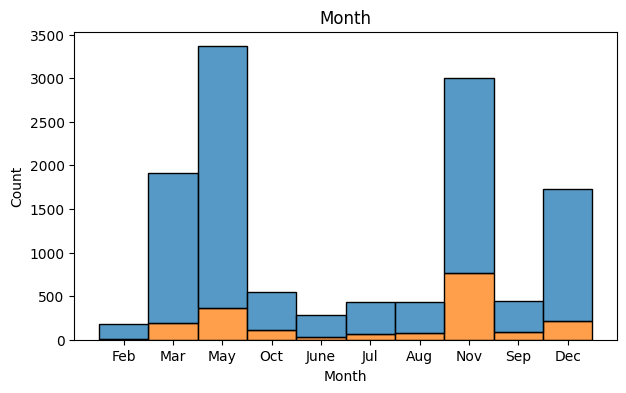

/opt/conda/lib/python3.10/site-packages/seaborn/_stats/counting.py:137: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bin_edges = np.histogram_bin_edges(vals, bins, binrange, weight)
/opt/conda/lib/python3.10/site-packages/seaborn/_stats/counting.py:176: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, edges = np.histogram(vals, **bin_kws, weights=weights, density=density)


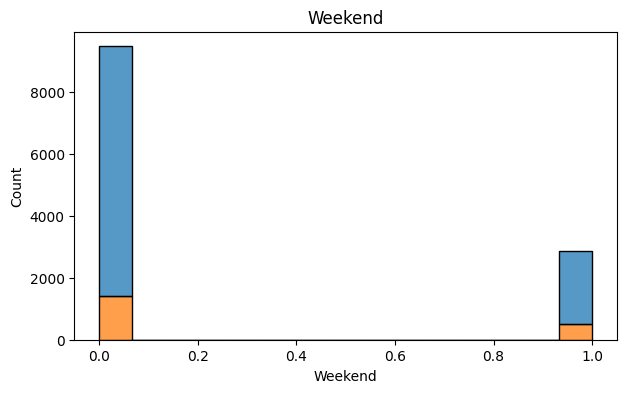

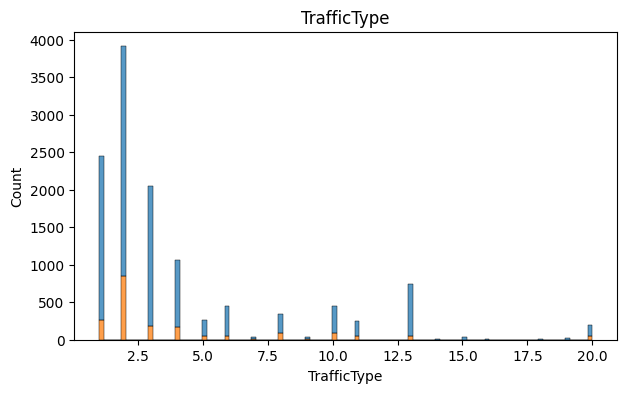

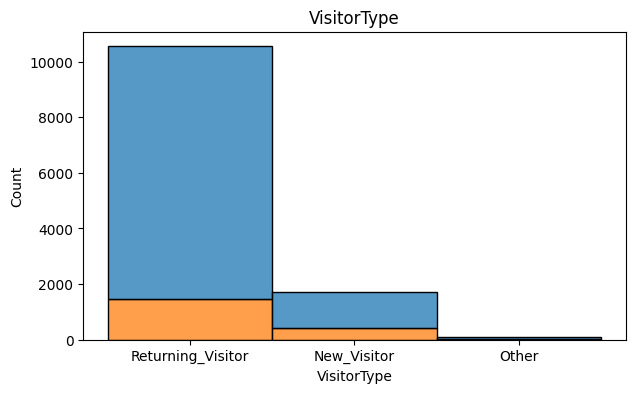

/opt/conda/lib/python3.10/site-packages/seaborn/_stats/counting.py:137: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bin_edges = np.histogram_bin_edges(vals, bins, binrange, weight)
/opt/conda/lib/python3.10/site-packages/seaborn/_stats/counting.py:176: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, edges = np.histogram(vals, **bin_kws, weights=weights, density=density)


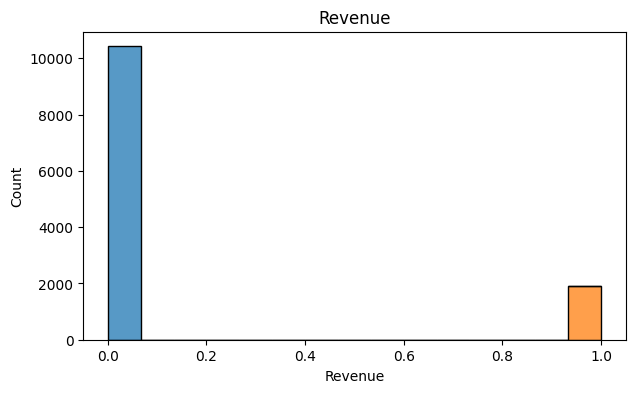

In [8]:
for i in categorical:
    plt.figure(figsize=(7, 4))
    plt.title(i)
    ax = sns.histplot(df, x=i, legend=False, hue='Revenue', multiple='stack')
#     ax.bar_label(ax.containers[0])
    plt.show()

These features has many infrequent categories: TrafficType, VisitorType, Browser, dan OperatingSystem

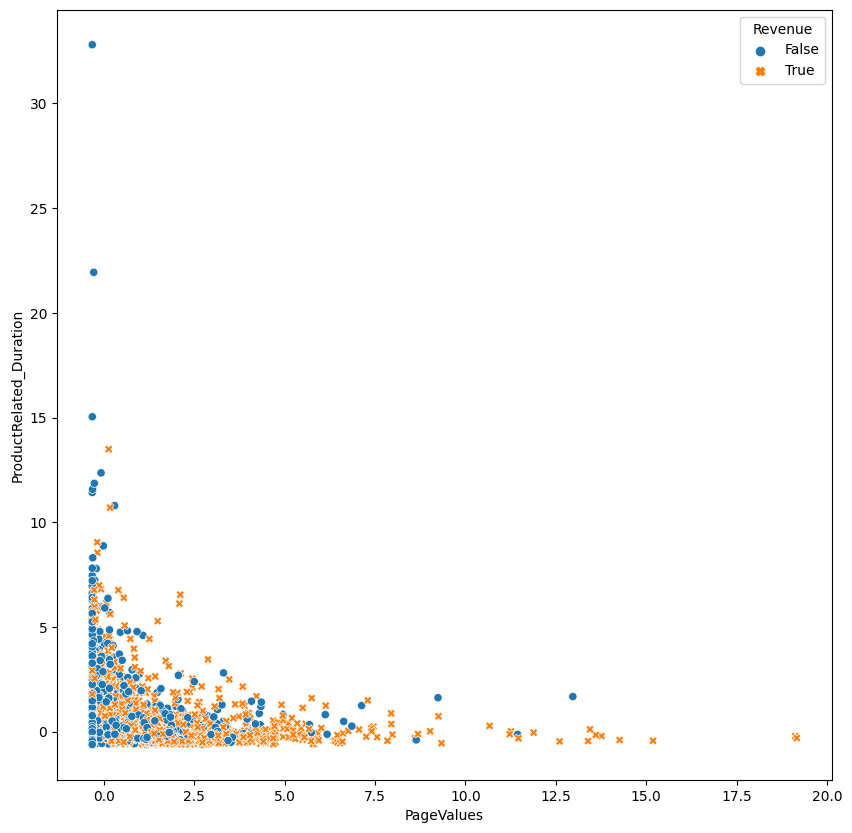

In [9]:
df_scaled = pd.DataFrame(StandardScaler().fit_transform(df[numerical]), columns=numerical)
df_scaled['Revenue'] = df['Revenue']
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_scaled, x='PageValues', y='ProductRelated_Duration', hue='Revenue', style='Revenue')
plt.show()

The lesser the time for the customers to browse related products, especially on popular pages, the more chance of a purchase will be.

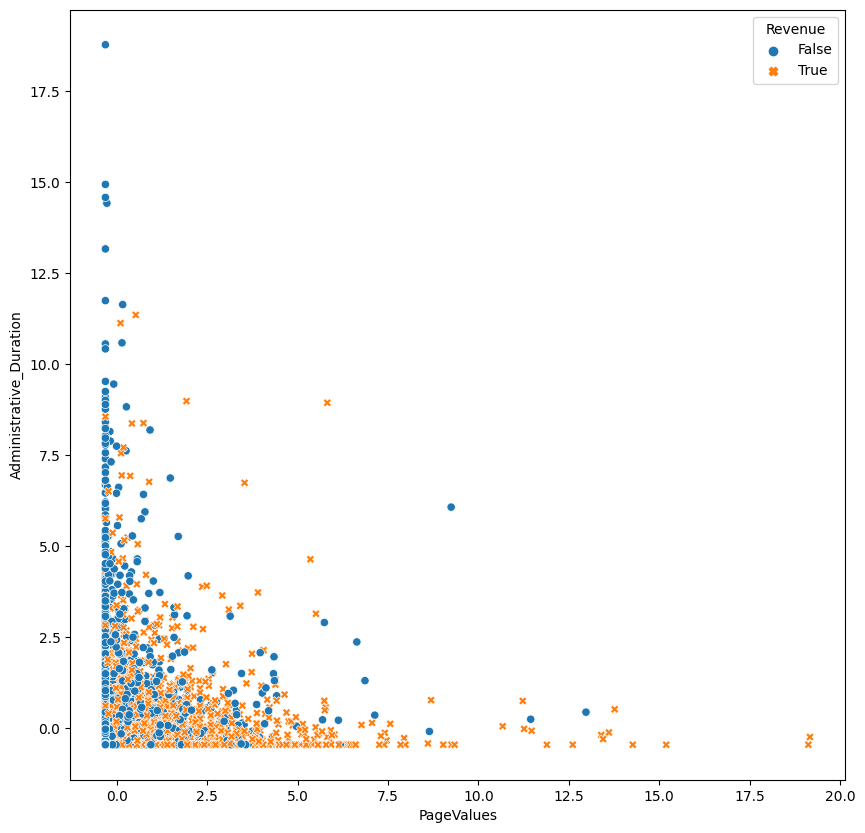

In [10]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_scaled, x='PageValues', y='Administrative_Duration', hue='Revenue', style='Revenue')
plt.show()

Quite similar to the previous plot, revenues tends to favor less administrative task. However, the Page Values also has quite a big influence 

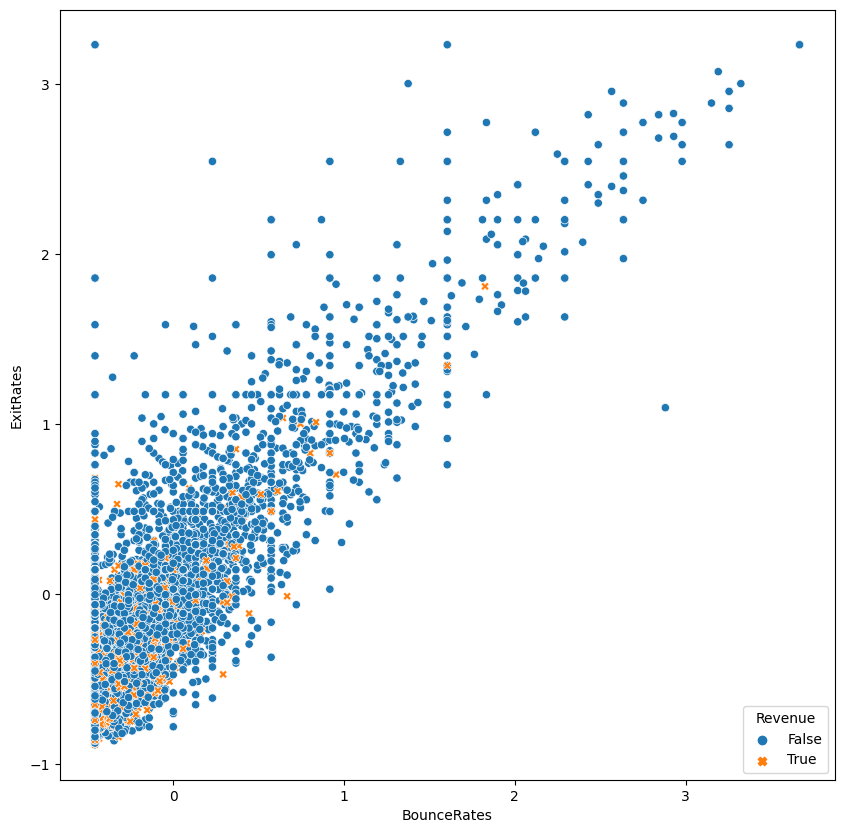

In [11]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_scaled, x='BounceRates', y='ExitRates', hue='Revenue', style='Revenue')
plt.show()

Pages with hight ExitRates dan low BounceRates generated more revenue.

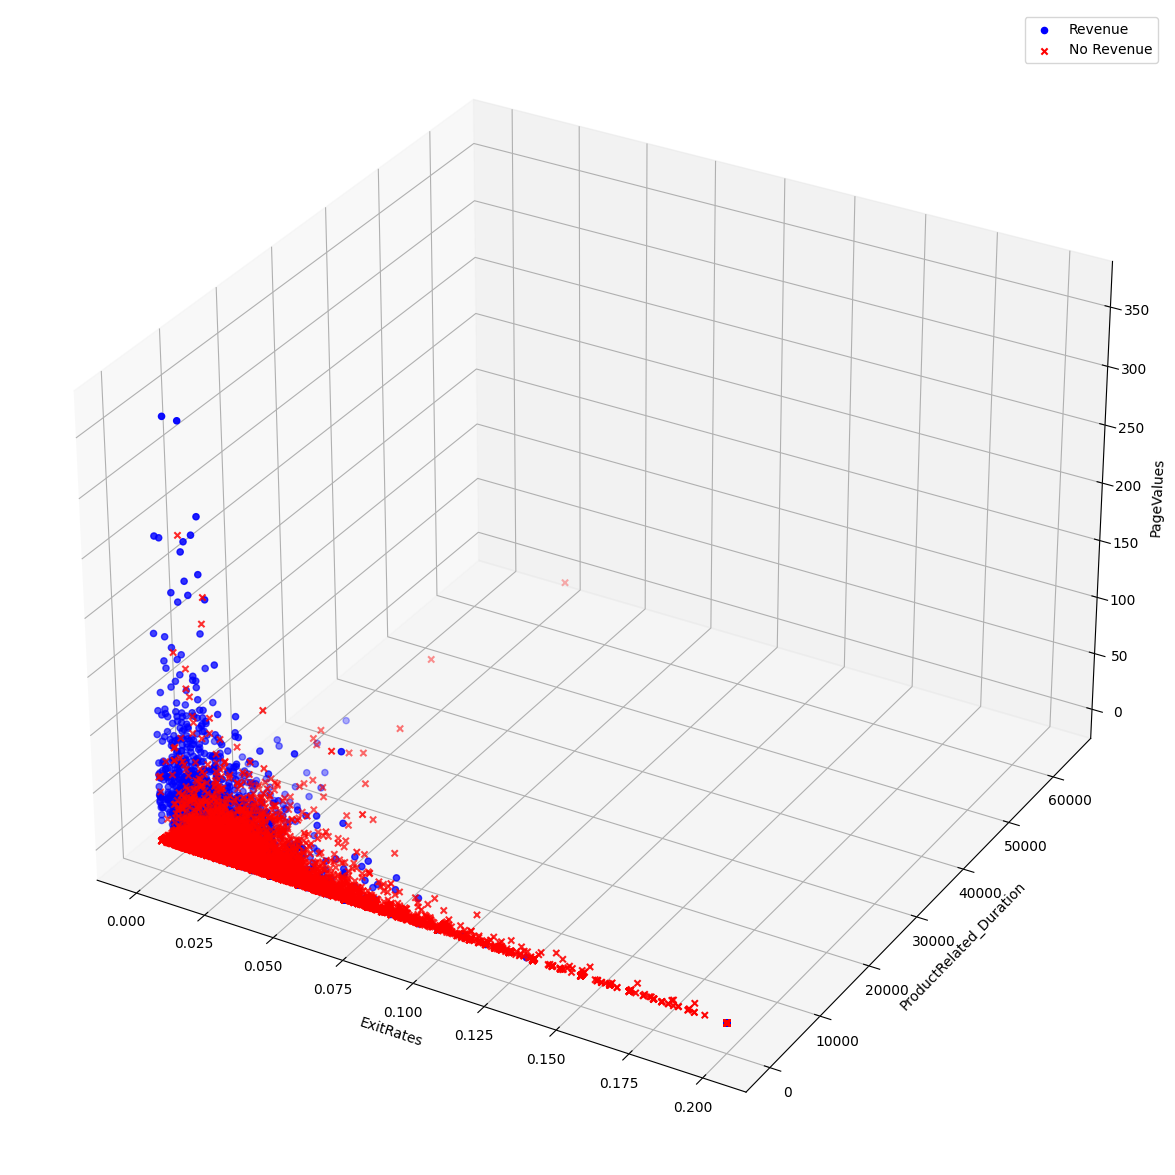

In [12]:
from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection='3d')

# z = df.iloc[:, [5, 7, 8, 17]].T.to_numpy()
z1 = df[df["Revenue"] == True].iloc[:, [7, 5, 8, 17]].T.to_numpy()
z2 = df[df['Revenue'] == False].iloc[:, [7, 5, 8, 17]].T.to_numpy()

ax.scatter(z1[0], z1[1], z1[2], c='blue', marker='o', label='Revenue')
ax.scatter(z2[0], z2[1], z2[2], c='red', marker='x', label='No Revenue')

ax.set_xlabel('ExitRates')
ax.set_ylabel('ProductRelated_Duration')
ax.set_zlabel('PageValues')
ax.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax.transAxes)
# ax.legend(handles=[z1_path, z2_path])

plt.show()

Revenue tends to favor rows with high PageValues, low ExitRates, and low ProductRelated_Duratio

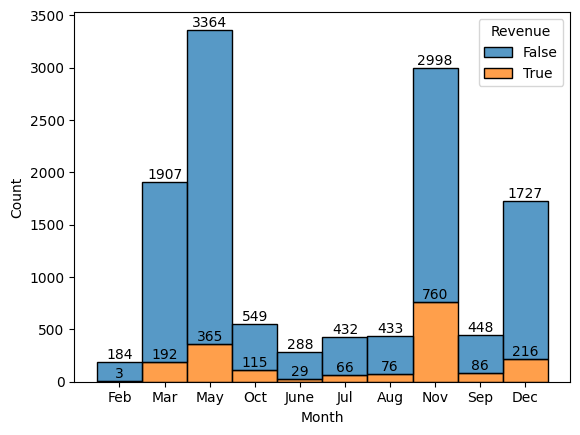

In [13]:
ax = sns.histplot(data=df,x='Month', hue='Revenue', multiple='stack')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

The most visitors are in May, November, March and December respectively. Meanwhile, the highest number of purchases was in November, May, December and March respectively.

<Axes: xlabel='Month', ylabel='count'>

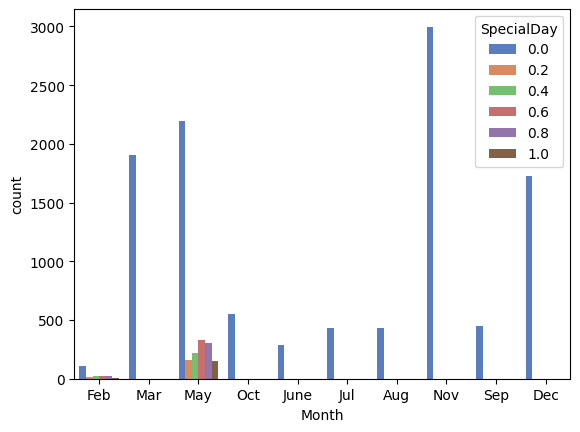

In [14]:
sns.countplot(df,x='Month',hue='SpecialDay', palette='muted')

The reason for the large number of transactions in May is the number of users who transacted close to the special day

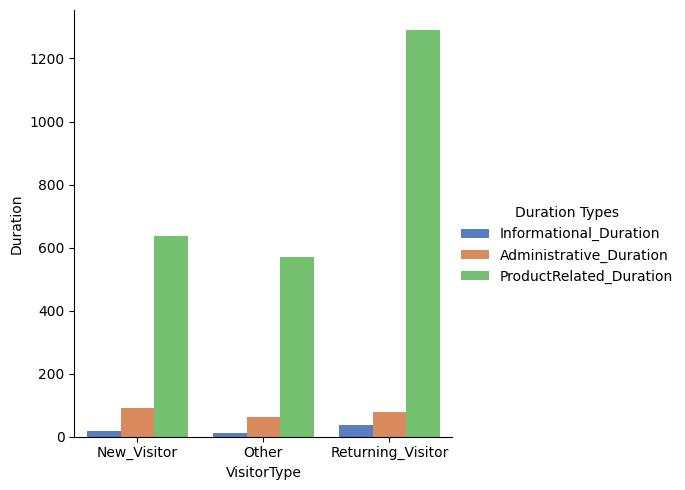

In [15]:
dfm = df[['Informational_Duration', 'Administrative_Duration', 'ProductRelated_Duration', 'VisitorType']].groupby(by='VisitorType').mean().reset_index()
dfm = pd.melt(dfm, id_vars='VisitorType', var_name='Duration Types', value_name='Duration')
sns.catplot(dfm, x='VisitorType', y='Duration', hue='Duration Types', kind='bar', palette='muted')

## Classification

In [16]:
df['Month'] = df['Month'].replace({
    "Jan": 1,
    "Feb": 2,
    "Mar": 3,
    "Apr": 4,
    "May": 5,
    "June": 6,
    "Jul": 7,
    "Aug": 8,
    "Sep": 9,
    "Oct": 10,
    "Nov": 11,
    "Dec": 12
})

df['VisitorType'] = df['VisitorType'].astype('category')
df['Weekend'] = df['Weekend'].astype('category')

df['VisitorType'] = df['VisitorType'].cat.codes
df['Weekend'] = df['Weekend'].cat.codes

df['Revenue'] = df['Revenue'].astype('int64')

In [17]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Revenue', axis=1), df['Revenue'], test_size=0.3, stratify=df['Revenue'], random_state=129395659, shuffle=True)

In [18]:
y_train.value_counts()

Revenue
0    7295
1    1336
Name: count, dtype: int64

In [19]:
categorical = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
numerical = ['Administrative', 'Administrative_Duration',
             'Informational', 'Informational_Duration',
             'ProductRelated', 'ProductRelated_Duration',
             'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

In [20]:
preprocessors = Pipeline([
    ('column transformer', ColumnTransformer([
        ("numerical", StandardScaler(), numerical),
        ("categorical", OneHotEncoder(sparse_output=False, min_frequency=10, handle_unknown='infrequent_if_exist'), categorical)
    ])),
    ('feature selection', SelectKBest(mutual_info_classif, k=20))
])
preprocessors

Pipeline(steps=[('column transformer',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues',
                                                   'SpecialDay']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                min_frequency=10,
                                                                sparse_output=False),
                                                  ['Month', 'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType', 'VisitorType',
                                                   'Weekend'])])),
                ('feature selection',
                 SelectKBest(k=20,
                             score_func=<function mutual_info_classif at 0x7e3e4b3dc940>))])

In [21]:
classifiers = [
    Pipeline_([
        ('smote', SMOTE()),
        ('xgboost', XGBClassifier(objective="binary:logistic")),
    ]),
    Pipeline_([
        ('smote', SMOTE(sampling_strategy=0.75)),
        ('near miss', NearMiss(version=2)),
        ('xgboost', XGBClassifier(objective="binary:logistic"))
    ]),
    Pipeline_([
        ('smote', SMOTE(sampling_strategy=0.75)),
        ('rus', RandomUnderSampler()),
        ('mlp', MLPClassifier(max_iter=300, learning_rate_init=0.00005))
    ]),
        Pipeline_([
        ('smote', SMOTE()),
        ('mlp', MLPClassifier(max_iter=300, learning_rate_init=0.00005)),
    ]),
    Pipeline_([
        ('smote', SMOTE(sampling_strategy=0.75)),
        ('near miss', NearMiss(version=2)),
        ('mlp', MLPClassifier(max_iter=300, learning_rate_init=0.00005))
    ]),
    Pipeline_([
        ('smote', SMOTE(sampling_strategy=0.75)),
        ('rus', RandomUnderSampler()),
        ('mlp', MLPClassifier(max_iter=300, learning_rate_init=0.00005))
    ]),
    Pipeline_([
        ('smote', SMOTE()),
        ('dtree', DecisionTreeClassifier()),
    ]),
    Pipeline_([
        ('smote', SMOTE(sampling_strategy=0.75)),
        ('near miss', NearMiss(version=2)),
        ('dtree', DecisionTreeClassifier())
    ]),
]

In [22]:
def kfold_crossvalidation(classifier, X, y):
    n_splits = 10
    kfold = StratifiedKFold(n_splits=n_splits, random_state=420024, shuffle=True)
    _aupr, _auroc, _f1 = 0, 0, 0
    for train, test in kfold.split(X, y):
        # labelling
        x_train, y_train = X.iloc[train], y.iloc[train]
        x_test, y_test = X.iloc[test], y.iloc[test]

        classifier.fit(x_train, y_train)
        y_pred = classifier.predict(x_test)

        _aupr += average_precision_score(y_test, y_pred)
        _auroc += roc_auc_score(y_test, y_pred)
        _f1 += f1_score(y_test, y_pred)

    return (_aupr/n_splits, _auroc/n_splits, _f1/n_splits)

In [23]:
X_trans = preprocessors.fit_transform(X_train, y_train)
X_trans = pd.DataFrame(X_trans, columns=preprocessors.get_feature_names_out())
preprocessors.get_feature_names_out()

array(['numerical__Administrative', 'numerical__Administrative_Duration',
       'numerical__Informational', 'numerical__Informational_Duration',
       'numerical__ProductRelated', 'numerical__ProductRelated_Duration',
       'numerical__BounceRates', 'numerical__ExitRates',
       'numerical__PageValues', 'categorical__Month_5',
       'categorical__Month_9', 'categorical__Month_11',
       'categorical__OperatingSystems_1',
       'categorical__OperatingSystems_2', 'categorical__Browser_2',
       'categorical__Browser_infrequent_sklearn', 'categorical__Region_1',
       'categorical__TrafficType_3', 'categorical__TrafficType_15',
       'categorical__TrafficType_20'], dtype=object)

In [24]:
for classifier in classifiers:
    print(kfold_crossvalidation(classifier, X_trans, y_train))

(0.46939303245732134, 0.7910620915476134, 0.6436052347494314)
(0.4056016402646826, 0.7902224023171079, 0.5912494728418616)


/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptro

(0.4551402413184687, 0.8317818493911414, 0.6374677029860364)


/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptro

(0.46129782524008345, 0.8344834272987107, 0.6429566134871569)


/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptro

(0.3886627749690211, 0.8139157289292098, 0.5715980680393955)


/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptro

(0.45867904823528727, 0.8328810150980622, 0.6406928073705057)
(0.38118477656300376, 0.7598421741430623, 0.5654657543839019)
(0.32641741295760457, 0.7453209037433134, 0.5090651836455069)


XGBoost with SMOTE will be the chosen approach

In [25]:
clf = Pipeline_([
    ('tomeks link', TomekLinks()),
    ('smote', SMOTE()),
    ('xgb', XGBClassifier())
])

In [26]:
grid_search = GridSearchCV(
    estimator=clf,
    param_grid={
        'xgb__max_depth': range(2, 7),
        'xgb__min_child_weight': range(1, 6)
    },
    scoring='f1',
    n_jobs=8,
    cv=10
)

grid_search.fit(X_trans, y_train)
grid_search.cv_results_

{'mean_fit_time': array([2.2301218 , 2.03372791, 1.971873  , 2.30540109, 1.95548995,
        2.12117665, 2.1243566 , 2.14501946, 2.1444242 , 2.10374393,
        2.39011953, 2.45348132, 2.36739068, 2.33010182, 2.66976242,
        2.81624517, 2.66404402, 2.66761227, 2.6255981 , 2.53432128,
        3.22058403, 3.01393235, 2.93311367, 3.29670913, 2.61155665]),
 'std_fit_time': array([0.08204514, 0.10677954, 0.05005091, 0.34734661, 0.02748444,
        0.01526249, 0.0122834 , 0.05249615, 0.04845746, 0.01960718,
        0.02214798, 0.09688711, 0.03727762, 0.01473051, 0.42665533,
        0.40383971, 0.01644166, 0.09316321, 0.08217378, 0.01885271,
        0.05804275, 0.06387492, 0.09210237, 0.31174905, 0.42589109]),
 'mean_score_time': array([0.02684851, 0.02446301, 0.02475731, 0.02528338, 0.02594895,
        0.02710207, 0.02475698, 0.02510042, 0.02377007, 0.02694936,
        0.02300742, 0.02679944, 0.0227463 , 0.02931652, 0.02705557,
        0.02872829, 0.02784989, 0.02487686, 0.02867446, 0.03

In [27]:
clf2 = Pipeline_([
    ('tomeks link', TomekLinks()),
    ('smote', SMOTE()),
    ('xgb', XGBClassifier(max_depth=2, min_child_weight=5))
])

In [28]:
grid_search = GridSearchCV(
    estimator=clf2,
    param_grid={
        'xgb__gamma': [0, 0.1, 0.2, 0.4, 1, 1.5]
    },
    scoring='f1',
    n_jobs=8,
    cv=10
)

grid_search.fit(X_trans, y_train)
grid_search.cv_results_['rank_test_score'], grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score']

(array([3, 6, 4, 2, 1, 5], dtype=int32),
 [{'xgb__gamma': 0},
  {'xgb__gamma': 0.1},
  {'xgb__gamma': 0.2},
  {'xgb__gamma': 0.4},
  {'xgb__gamma': 1},
  {'xgb__gamma': 1.5}],
 array([0.67247516, 0.66872805, 0.67181144, 0.67329694, 0.67565315,
        0.67047962]))

In [29]:
model = Pipeline_([
    ('column transformer', ColumnTransformer([
        ("numerical", StandardScaler(), numerical),
        ("categorical", OneHotEncoder(sparse_output=False, min_frequency=10, handle_unknown='infrequent_if_exist'), categorical)
    ])),
    ('feature selection', SelectKBest(mutual_info_classif, k=20)),
    ('tomeks link', TomekLinks()),
    ('smote', SMOTE()),
    ('xgb', XGBClassifier(max_depth=2, min_child_weight=2, gamma=0.4))
])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Revenue', axis=1), df['Revenue'], test_size=0.3, stratify=df['Revenue'], random_state=6539273, shuffle=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
aupr = average_precision_score(y_test, y_pred)
auroc = roc_auc_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print('auPRC:', average_precision_score(y_test, y_pred))
print('auROC:', roc_auc_score(y_test, y_pred))
print('f1:', f1_score(y_test, y_pred))

auPRC: 0.485936408021175
auROC: 0.8314013297224041
f1: 0.664624808575804


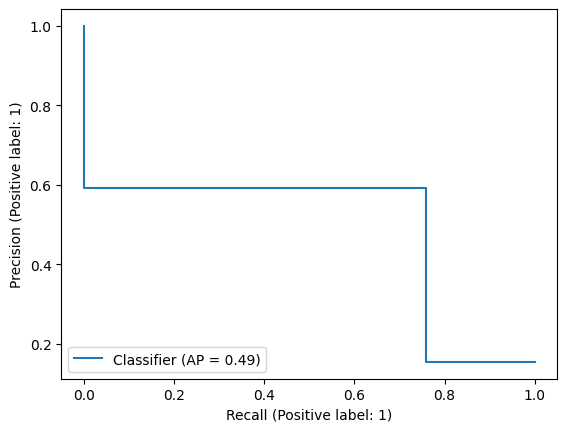

In [31]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred)
plt.show()

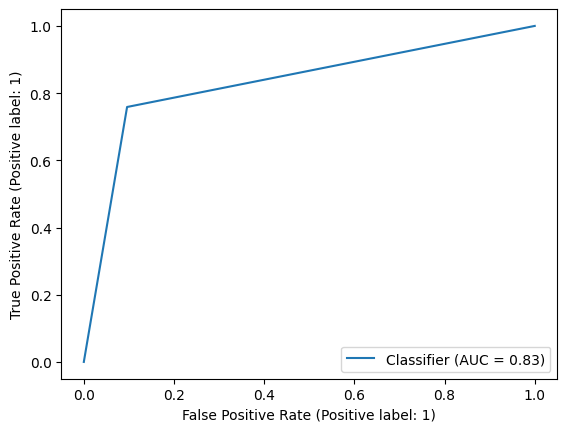

In [32]:
RocCurveDisplay.from_predictions(y_test, y_pred)
plt.show()

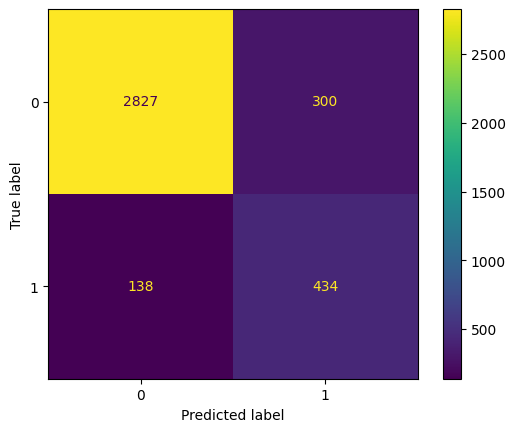

In [33]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()